# Notebook 0: Attached CFPB Dataset Audit

This notebook validates the attached `complaints.csv`, performs deterministic preprocessing,
and records the decisions used by the Milestone 3 pipeline.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.preprocessing import normalize_complaint, is_scam_candidate
RAW = PROJECT_ROOT / "data/raw/complaints.csv"
OUT = PROJECT_ROOT / "data/processed"
OUT.mkdir(parents=True, exist_ok=True)
COL_NARR = "Consumer complaint narrative"
COL_TAGS = "Tags"
COL_ID = "Complaint ID"
COL_PROD = "Product"
COL_SUB = "Sub-product"
SEED = 42
print("Project root:", PROJECT_ROOT)
print("CSV:", RAW)

Project root: /mnt/data/cfpb_fraud_intelligence_milestone3
CSV: /mnt/data/cfpb_fraud_intelligence_milestone3/data/raw/complaints.csv


In [2]:
df = pd.read_csv(RAW, low_memory=False)
required = {COL_NARR, COL_TAGS, COL_ID, COL_PROD, COL_SUB}
missing = required.difference(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Missing narratives: {df[COL_NARR].isna().sum():,}")
print(f"Duplicate complaint IDs: {df[COL_ID].duplicated().sum():,}")
df.head(3)

Rows: 25,777
Columns: 14
Missing narratives: 0
Duplicate complaint IDs: 0


,Date received,Product,Sub-product,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,1/6/2020,"Money transfer, virtual currency, or money ser...",Mobile or digital wallet,"According to Federal Law, XXXX is legal. I ope...",NaN,"Block, Inc.",FL,34683,Older American,1/6/2020,Closed with explanation,Yes,NaN,3486993
1,10/4/2018,"Money transfer, virtual currency, or money ser...",Traveler's check or cashier's check,I was a victim of a fake Cashiers Check scam. ...,NaN,FIFTH THIRD FINANCIAL CORPORATION,IN,46220,NaN,10/4/2018,Closed with explanation,Yes,NaN,3037645
2,4/27/2021,"Money transfer, virtual currency, or money ser...",Domestic (US) money transfer,"On XX/XX/2021, my husband received an email fr...",Company has responded to the consumer and the ...,"BANK OF AMERICA, NATIONAL ASSOCIATION",PA,19355,Older American,4/27/2021,Closed with explanation,Yes,NaN,4329943


In [3]:
df = df[df[COL_NARR].notna()].copy()
df[COL_NARR] = df[COL_NARR].astype(str)
df["raw_word_count"] = df[COL_NARR].str.split().str.len()
df["is_older"] = df[COL_TAGS].astype(str).str.contains("Older American", na=False)
print(df["raw_word_count"].describe().round(1))
print(f"Older-consumer share: {df['is_older'].mean():.1%}")
print("\nTop sub-products:")
print(df[COL_SUB].value_counts().head(12).to_string())

count    25777.0
mean       237.8
std        288.7
min          1.0
25%         84.0
50%        160.0
75%        288.0
max       5699.0
Name: raw_word_count, dtype: float64
Older-consumer share: 9.8%

Top sub-products:
Sub-product
Mobile or digital wallet                            8712
Domestic (US) money transfer                        8007
Virtual currency                                    4023
International money transfer                        1745
Credit repair services                               998
Check cashing service                                556
Foreign currency exchange                            338
Money order, traveler's check or cashier's check     320
Debt settlement                                      248
Traveler's check or cashier's check                  211
Refund anticipation check                            139
Money order                                          125


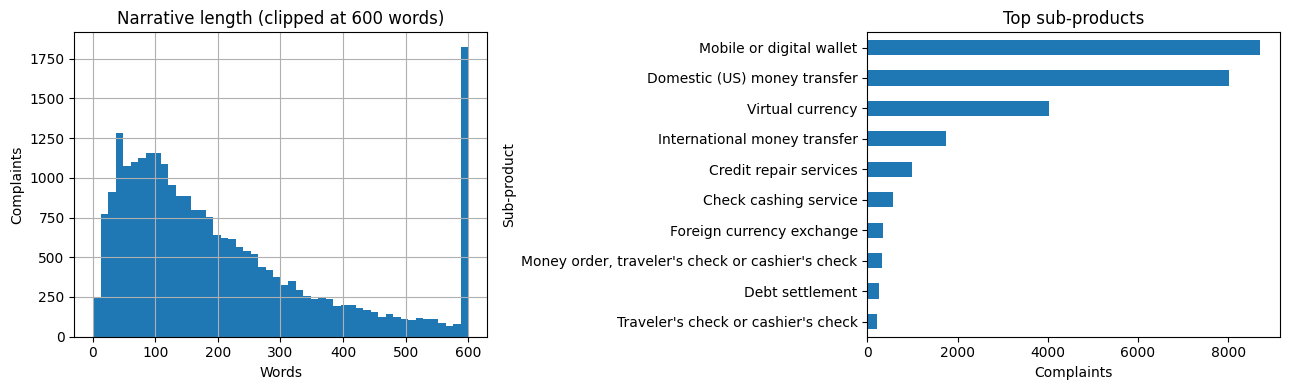

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["raw_word_count"].clip(upper=600).hist(bins=50, ax=axes[0])
axes[0].set(title="Narrative length (clipped at 600 words)", xlabel="Words", ylabel="Complaints")
df[COL_SUB].value_counts().head(10).sort_values().plot.barh(ax=axes[1])
axes[1].set(title="Top sub-products", xlabel="Complaints")
plt.tight_layout()
plt.show()

In [5]:
df["clean_text"] = df[COL_NARR].map(normalize_complaint)
df["word_count"] = df["clean_text"].str.split().str.len()
raw_rows = len(df)
short_mask = df["word_count"] < 10
short_removed = int(short_mask.sum())
df = df.loc[~short_mask].copy()
duplicates_removed = int(df.duplicated(subset=["clean_text"]).sum())
df = df.drop_duplicates(subset=["clean_text"]).copy()
df["regex_scam_flag"] = df["clean_text"].map(is_scam_candidate)
print(f"Raw narrative rows: {raw_rows:,}")
print(f"Removed under 10 words: {short_removed:,}")
print(f"Removed exact normalized duplicates: {duplicates_removed:,}")
print(f"Rows after deterministic cleaning: {len(df):,}")
print(f"Regex scam-audit match rate: {df['regex_scam_flag'].mean():.1%}")

Raw narrative rows: 25,777
Removed under 10 words: 94
Removed exact normalized duplicates: 107
Rows after deterministic cleaning: 25,576
Regex scam-audit match rate: 65.8%


## Inclusion decision

The regex audit does not define the final dataset. It misses obvious scams whose narratives do not
contain the specific trigger words in the rule. Because the attached CSV matches the approximate
25,000-record working corpus described in Milestone 2, the pipeline keeps all cleaned rows and lets
unsupervised clustering, noise detection, and human topic review determine which archetypes are usable.

In [6]:
unmatched = df.loc[~df["regex_scam_flag"], [COL_SUB, COL_NARR]].copy()
audit_terms = r"winnings|leasing agents|never got the keys|buyer|holding my funds|send the required fee"
false_negative_examples = unmatched[
    unmatched[COL_NARR].str.contains(audit_terms, case=False, regex=True, na=False)
].head(5)
pd.set_option("display.max_colwidth", 250)
false_negative_examples

,Sub-product,Consumer complaint narrative
9,International money transfer,"Dear CFPB Government, This is XXXX XXXX, we got a payment XXXX from XXXX XXXX XXXX XXXX company on XXXX XXXX XXXX, we contact a man name XXXX XXXX , he paid us by PayPal . We delivered the packages on XXXX XX/XX/XXXX, the XXXX tracking number is ..."
29,Mobile or digital wallet,{$2500.00} was scammed from me using Zelle. I contacted XXXX bank who failed to reimburse me because the withdrawals were approved by me. \n\nI was trying to sell an item on XXXX market place. Buyer supposedly sent the money with Zelle. I got an ...
51,Mobile or digital wallet,"After receiving {$500.00} payment through an invoice, my account was permanently limited for no reason. The buyer was satisfied and confirmed that they have the product so the 21 day hold was released, after that I attempted to send an instant tr..."
135,Mobile or digital wallet,"On XX/XX/year>, PayPal permanently limited my account without providing a valid reason, despite my compliance with their terms and conditions. They are now holding my funds for 120 days without proper justification. \n\nBackground : I had an acti..."
172,Domestic (US) money transfer,I originally sold a phone through ebay for XXXX which the buyer paid through paypal. Paypal contacted me and said the buyer filed a dispute with their bank and the bank sided with the buyer. Problem is XXXX shows the item delivered and paypal sh...


In [7]:
df["clean_text"] = df["clean_text"].map(lambda x: " ".join(x.split()[:250]))
df.to_csv(OUT / "complaints_clean.csv.gz", index=False, compression="gzip")
report = {
    "raw_rows": int(raw_rows),
    "missing_narratives": 0,
    "short_rows_removed": int(short_removed),
    "exact_normalized_duplicates_removed": int(duplicates_removed),
    "rows_after_cleaning": int(len(df)),
    "regex_scam_audit_match_rate": float(df["regex_scam_flag"].mean()),
    "older_consumer_share": float(df["is_older"].mean()),
    "median_raw_word_count": float(df["raw_word_count"].median()),
    "top_subproducts": {str(k): int(v) for k, v in df[COL_SUB].value_counts().head(12).items()},
}
with open(OUT / "preprocessing_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)
print(json.dumps(report, indent=2))
print("\nSaved:", OUT / "complaints_clean.csv.gz")

{
  "raw_rows": 25777,
  "missing_narratives": 0,
  "short_rows_removed": 94,
  "exact_normalized_duplicates_removed": 107,
  "rows_after_cleaning": 25576,
  "regex_scam_audit_match_rate": 0.6577650922740069,
  "older_consumer_share": 0.09809978104472944,
  "median_raw_word_count": 162.0,
  "top_subproducts": {
    "Mobile or digital wallet": 8687,
    "Domestic (US) money transfer": 7920,
    "Virtual currency": 4000,
    "International money transfer": 1730,
    "Credit repair services": 968,
    "Check cashing service": 549,
    "Foreign currency exchange": 335,
    "Money order, traveler's check or cashier's check": 317,
    "Debt settlement": 247,
    "Traveler's check or cashier's check": 210,
    "Refund anticipation check": 138,
    "Money order": 125
  }
}

Saved: /mnt/data/cfpb_fraud_intelligence_milestone3/data/processed/complaints_clean.csv.gz


## Next step

Run `01_dataset_preparation_revised.ipynb` to compute MiniLM embeddings, benchmark HDBSCAN
configurations, fit BERTopic, and generate the manual topic-review template. Do not train the final
classifier until topics have human-readable labels and incoherent topics are rejected.